### Create anndata object from Visium HD dataset of colorectal cancer and perform QC
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Creation date:** 30th of October 2024
- **Last modified date:** 30th of October 2024

### Import packages

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squidpy as sq
import anndata as ad
import muon as mu
import h5py
import pathlib
import json
from PIL import Image
from datetime import datetime

### Upload dataset

In [2]:
base_dir = 'data/VisiumHD_CRC/binned_outputs'

In [3]:
def read_visium_hd_data(base_path, resolution="008um"):
    """
    Read VisiumHD data and create an AnnData object
    
    Parameters:
    -----------
    base_path : str
        Path to the directory containing the VisiumHD data files
    resolution : str
        Resolution to use ("002um", "008um", or "016um")
        
    Returns:
    --------
    adata : AnnData
        Annotated data matrix with spatial information
    """
    base_path = pathlib.Path(base_path)
    
    # Read the count matrix
    matrix_path = base_path / f"square_{resolution}/raw_feature_bc_matrix.h5"
    adata = sc.read_10x_h5(matrix_path)
    
    # Read spatial coordinates
    positions_path = base_path / f"square_{resolution}/tissue_positions.parquet"
    spatial_coords = pd.read_parquet(positions_path)
    
    # Extract barcode from the index name (assuming format like "square_008um_0")
    adata.obs['spot_id'] = [f"square_{resolution}_{i}" for i in range(len(adata.obs))]
    adata.obs_names = adata.obs['spot_id']
    
    # Make spot_id the index of spatial_coords for matching
    spatial_coords['spot_id'] = [f"square_{resolution}_{i}" for i in range(len(spatial_coords))]
    spatial_coords.set_index('spot_id', inplace=True)
    
    # Match spatial coordinates to spots in the count matrix
    matched_coords = spatial_coords.loc[adata.obs_names]
    
    # Add spatial coordinates to adata
    adata.obsm['spatial'] = matched_coords[['pxl_col_in_fullres', 'pxl_row_in_fullres']].values
    
    # Add the full spatial information to obs
    for col in matched_coords.columns:
        if col not in ['pxl_col_in_fullres', 'pxl_row_in_fullres']:
            adata.obs[col] = matched_coords[col]
    
    # Read scale factors
    with open(base_path / f"square_{resolution}/scalefactors_json.json", 'r') as f:
        scalefactors = json.load(f)
    adata.uns['spatial'] = {
        'scale_factors': scalefactors
    }
    
    # Add images
    image_paths = {
        'hires': base_path / f"square_{resolution}/tissue_hires_image.png",
        'lowres': base_path / f"square_{resolution}/tissue_lowres_image.png"
    }
    
    adata.uns['spatial']['images'] = {}
    for img_type, img_path in image_paths.items():
        if img_path.exists():
            img = plt.imread(img_path)
            adata.uns['spatial']['images'][img_type] = img
    
    return adata

In [4]:
adata_002um = read_visium_hd_data(base_dir, resolution="002um")
adata_002um

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 9468111 × 37082
    obs: 'spot_id', 'barcode', 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

### QC

In [5]:
sc.pp.filter_cells(adata_002um, min_counts=10)
sc.pp.filter_genes(adata_002um, min_cells=5)

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata_002um

AnnData object with n_obs × n_vars = 5722033 × 18932
    obs: 'spot_id', 'barcode', 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

In [7]:
sc.pp.calculate_qc_metrics(adata_002um, inplace=True, percent_top= None, log1p = False)

In [8]:
adata_002um.var['mt'] = adata_002um.var_names.str.startswith('MT-') 
adata_002um.var['ribo'] = adata_002um.var_names.str.startswith('RPS','RPL')
sc.pp.calculate_qc_metrics(adata_002um, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [9]:
adata_002um.var_names_make_unique()

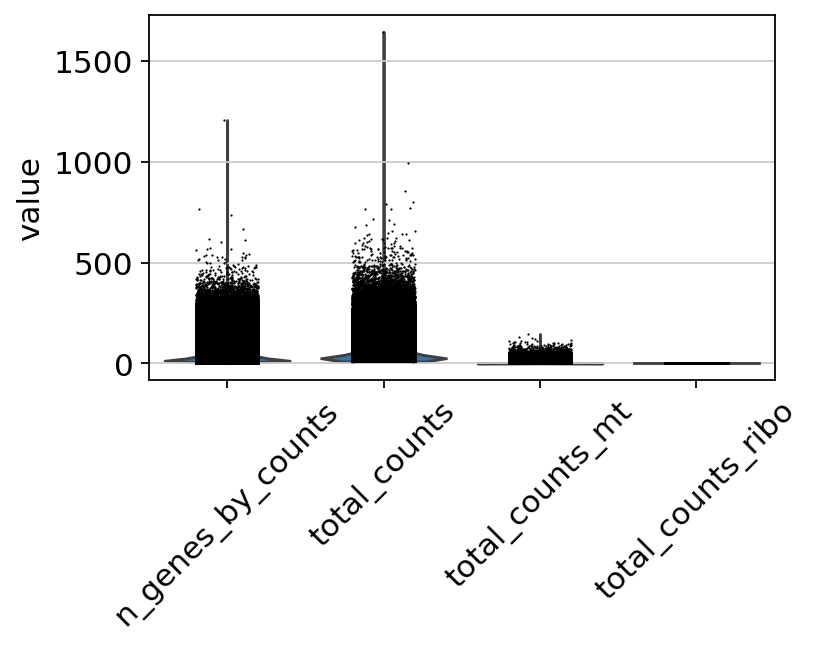

In [10]:
#sc.set_figure_params(figsize=(5, 3))
#sc.pl.violin(adata_002um, ['n_genes_by_counts', 'total_counts', 'total_counts_mt','total_counts_ribo'],
#             jitter = 0.2, rotation = 45)

+ Calculate leiden clustering

In [11]:
adata_002um.layers["counts"] = adata_002um.X.copy()

In [12]:
sc.pp.normalize_total(adata_002um)
sc.pp.log1p(adata_002um)

In [ ]:
sc.pp.pca(adata_002um)
sc.pp.neighbors(adata_002um)
sc.tl.umap(adata_002um)
sc.tl.leiden(adata_002um)

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_238288/200965038.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_002um)


In [ ]:
sq.pl.spatial_scatter(
    adata_002um,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

In [ ]:
adata_002um.X = adata_002um.layers["counts"].copy()

In [ ]:
project = 'NicheCompass'
species = 'hs'
atribute = 'VisiumHD_CRC_002um'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

adata_002um.uns['processing_history'] = {
    'timestamp': timestamp,
    'preprocessing_step': 'QC_filtering',
    'preprocessing_parameters': {
        'min_counts': 10,
        'min_genes': 5
    }
}

adata_002um.write_h5ad(f"data/VisiumHD_CRC/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [2]:
adata = sc.read_h5ad(f"data/VisiumHD_CRC/NicheCompass_hs_VisiumHD_CRC_002um_AM_01112024_184529_raw.h5ad")

In [9]:
adata.obs['leiden_1'] = adata.obs['leiden'].copy()

In [ ]:
sc.tl.leiden(adata, resolution = 0.6)

/tmp/ipykernel_356148/4134666628.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.6)


/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


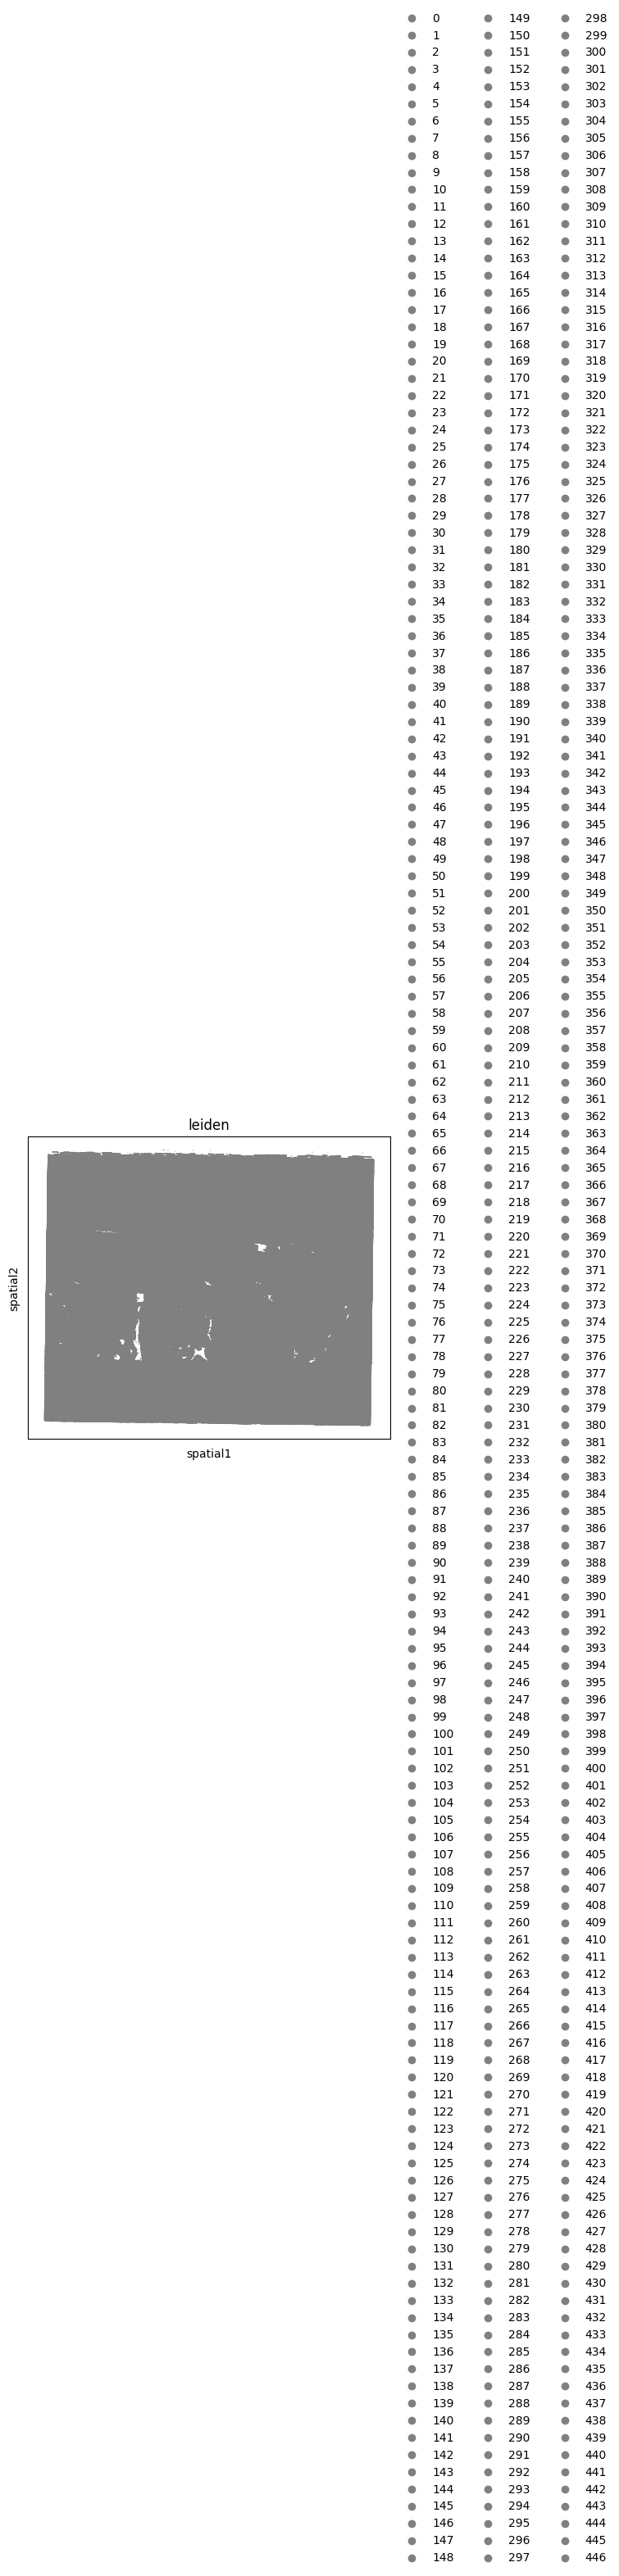

In [4]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)